# Plot Classwise Covariance Matrices
Load and visualize the classwise covariance matrices saved during validation.

In [293]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import re

In [294]:
def dataset_info(dataset, model, model_path):
    log_file_path = os.path.join("experiments", model, dataset, model_path, "log.txt")
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        info = {}
        for line_num, line in enumerate(lines):
            if line_num == 0:
                continue
            if "Epoch" in line:
                break
            
            if ":" in line:
                key, value = line.split(":", 1)
                info[key.strip()] = value.strip()
    return info


def test_metrics(dataset, model, model_path):
    metrics = {}
    with open(os.path.join("experiments", model, dataset, model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"y_accuracy:\s*([0-9.]+)", test_line)[0]
        c_accuracy = re.findall(r"c_accuracy:\s*([0-9.]+)", test_line)[0]
        c_auc = re.findall(r"c_AUROC:\s*([0-9.]+)", test_line)[0]
        metrics["y_accuracy"] = float(y_accuracy)
        metrics["c_accuracy"] = float(c_accuracy)
        metrics["c_auc"] = float(c_auc)
    return metrics   



dataset = "synthetic_res_scbm"
model = "scbm_residual"
model_path = "alpha_1.0_beta_1.0_gamma_0_rho_0.7_ratio_pairs_0.3_200_epochs_2026-05-28_17-24-11_805d7"

dataset_info_dict = dataset_info(dataset, model, model_path)
print(dataset_info_dict)
        

{'Concepts linked to residuals (concept index, residual index)': '[(9, 3), (0, 0), (5, 1), (7, 0), (0, 4), (6, 2), (9, 1), (4, 3), (9, 0), (0, 2), (3, 4), (2, 3), (8, 1), (1, 4), (8, 2)]', 'Task weight s for concepts': '[0.18481311202049255, -0.7912485003471375, 0.0, 0.5828979015350342, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]', 'Task weight s for residuals': '[0.0, 0.0, 0.0, -0.7034295201301575, -0.7107649445533752]', 'rho_cr (correlation between linked concepts and residuals)': '0.7', 'alpha': '1.0, beta: 1.0, gamma: 0', 'data_dir': '/cluster/home/smarcou/work/Data/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.7_pair_ratio_0.3_r_sparsity_0.5_c_sparsity_0.3_sigmax_0.5_seed_0_v1'}


In [295]:
from collections import defaultdict

def print_residual_links(concept_to_residual_pairs):
    """
    Prints which concepts are linked to each residual.

    concept_to_residual_pairs should be a list like:
        [(9, 3), (0, 0), (5, 1), ...]
    where each pair is (concept_index, residual_index).
    """

    residual_to_concepts = defaultdict(list)

    for concept_idx, residual_idx in concept_to_residual_pairs:
        residual_to_concepts[residual_idx].append(concept_idx)

    for residual_idx in sorted(residual_to_concepts.keys()):
        concept_list = residual_to_concepts[residual_idx]

        concept_string = ", ".join([f"c{i}" for i in concept_list])

        print(f"r{residual_idx} is linked to {concept_string}")

In [296]:
models = [("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_0.0_gamma_0_rho_0_200_epochs_2026-05-27_14-04-30_12aef"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_0.5_gamma_0_rho_0_200_epochs_2026-05-27_14-04-15_75911"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_1.0_gamma_0_rho_0_200_epochs_2026-05-27_14-04-15_86c3d"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_2.0_gamma_0_rho_0_200_epochs_2026-05-27_14-04-15_6e239"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_1.0_gamma_0_rho_0.3_200_epochs_2026-05-27_14-12-36_51f8c"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_1.0_gamma_0_rho_0.7_200_epochs_2026-05-27_14-17-16_91217"),]

    
models = [("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_1.0_gamma_0_rho_0.7_ratio_pairs_0.3_200_epochs_2026-05-28_17-24-11_805d7")]


models = [("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_0_gamma_0_rho_0_ratio_pairs_0.5_200_epochs_1_residual_2026-05-29_12-28-20_440fd"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_1.0_gamma_0_rho_0_ratio_pairs_0.5_200_epochs_1_residual_2026-05-29_12-28-15_91652"),
          ("synthetic_res_scbm", "scbm_residual", "alpha_1.0_beta_10_gamma_0_rho_0_ratio_pairs_0.5_200_epochs_1_residual_2026-05-29_12-28-20_ec8ca")]


# Model weight analysis

In [297]:
from omegaconf import OmegaConf
import ast
from models.models import create_model


def get_config_dict(dataset, model, model_path):
    log_file = os.path.join("experiments", model, dataset, model_path, "log.txt")
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            lines = f.readlines()
            info_dict = lines[0].strip()  
            info_dict =  ast.literal_eval(info_dict)
            
        return info_dict
    else:
        raise FileNotFoundError(f"Log file not found: {log_file}")
    
    


def get_final_layer_weights(dataset, model_name, model_path):
    full_model_path = os.path.join("experiments", model_name, dataset, model_path, "model.pth")
    if os.path.exists(full_model_path):
        model_state = torch.load(full_model_path, map_location=torch.device('cpu'))
        config_dict = get_config_dict(dataset, model_name, model_path)
        config = OmegaConf.create(config_dict)
        model = create_model(config)
        model.load_state_dict(model_state)
        print(f"Loaded model from {full_model_path}")
        W = model.head[0].weight.detach().cpu()
        W_c = W[:, :config.data.num_concepts]
        if model_name == "scbm_residual":
            W_r = W[:, config.data.num_concepts:]
        else:
            W_r = None  
        return W_c, W_r
    else:
        raise FileNotFoundError(f"Model file not found: {full_model_path}")

# Correlation between residual dimensions and task head weights

In [298]:
def corr_matrix(A, B, eps=1e-8):
    """
    A: Tensor of shape (N, d_a)
    B: Tensor of shape (N, d_b)

    Returns:
        Correlation matrix of shape (d_a, d_b)
        entry[j, k] = corr(A[:, j], B[:, k])
    """
    A = A.detach().cpu().float()
    B = B.detach().cpu().float()

    A = A - A.mean(dim=0, keepdim=True)
    B = B - B.mean(dim=0, keepdim=True)

    A = A / (A.std(dim=0, keepdim=True) + eps)
    B = B / (B.std(dim=0, keepdim=True) + eps)

    return (A.T @ B) / (A.shape[0] - 1)

In [299]:
def get_data_dir_path_from_model_log(dataset, model, model_path):
    log_file_path = os.path.join("experiments", model, dataset, model_path, "log.txt")
    with open(log_file_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith("data_dir:"):
                data_dir_line = line
                break
        data_dir = data_dir_line.split("data_dir:")[1].strip()
        data_dir = "/".join(data_dir.split("/")[-1:])
    full_datapath = os.path.join("datasets", dataset, data_dir)
    return full_datapath

def get_metrics_dataset_linear_model(dataset, model, model_path):
    full_data_path = get_data_dir_path_from_model_log(dataset, model, model_path)
    data_dir_name = full_data_path.split("/")[-1]
    linear_models_dir = os.path.join("experiments", "linear_head", dataset)
    for model_dir in os.listdir(linear_models_dir):
        model_name_start = data_dir_name + "_trueResUsed_False"
        if model_dir.startswith(model_name_start):
            linear_model_path = model_dir
            break
    with open(os.path.join(linear_models_dir, linear_model_path, "log.txt"), "r") as f:
        lines = f.readlines()
        for line in lines:
            if "Test" in line:
                test_line = line
                break
        y_accuracy = re.findall(r"Final Test Accuracy:\s*([0-9.]+)", test_line)[0]
        
    return float(y_accuracy)



In [300]:
def corr_matrix(A, B, eps=1e-8):
    """
    A: Tensor of shape (N, d_a)
    B: Tensor of shape (N, d_b)

    Returns:
        Correlation matrix of shape (d_a, d_b)
        entry[j, k] = corr(A[:, j], B[:, k])
    """
    A = A.detach().cpu().float()
    B = B.detach().cpu().float()

    A = A - A.mean(dim=0, keepdim=True)
    B = B - B.mean(dim=0, keepdim=True)

    A = A / (A.std(dim=0, keepdim=True) + eps)
    B = B / (B.std(dim=0, keepdim=True) + eps)


    return (A.T @ B) / (A.shape[0] - 1)


# ------------------------------------------------------------
# Helper function for plotting
# ------------------------------------------------------------
def plot_corr_heatmap(corr, x_label, y_label, title, figsize=(7, 5)):
    corr = corr.detach().cpu()

    plt.figure(figsize=figsize)
    plt.imshow(corr.numpy(), vmin=-1, vmax=1)
    plt.colorbar(label="Pearson correlation")

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    plt.xticks(np.arange(corr.shape[1]))
    plt.yticks(np.arange(corr.shape[0]))

    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            plt.text(
                j,
                i,
                f"{corr[i, j].item():.2f}",
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()



--- New model: scbm_residual ---
----------
Linear model test accuracy: 1.000
----------

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 0, gamma: 0
rho: 0
----------



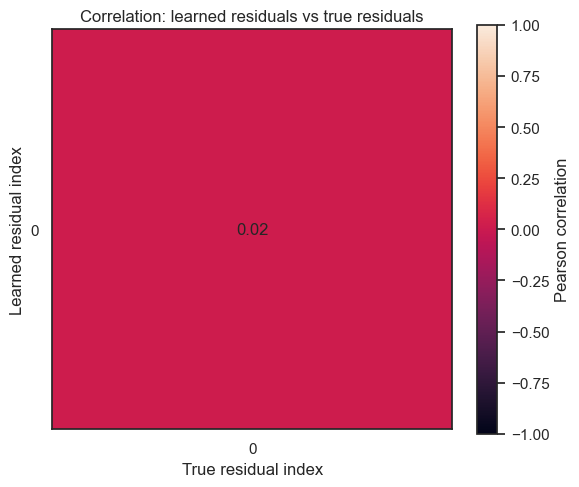

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 0, gamma: 0
rho: 0
Concepts linked to residuals (concept index, residual index): [(9, 0), (1, 0), (5, 0), (0, 0), (2, 0)]
----------


--- New model: scbm_residual ---
----------
Linear model test accuracy: 0.693
----------

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 1.0, gamma: 0
rho: 0
----------



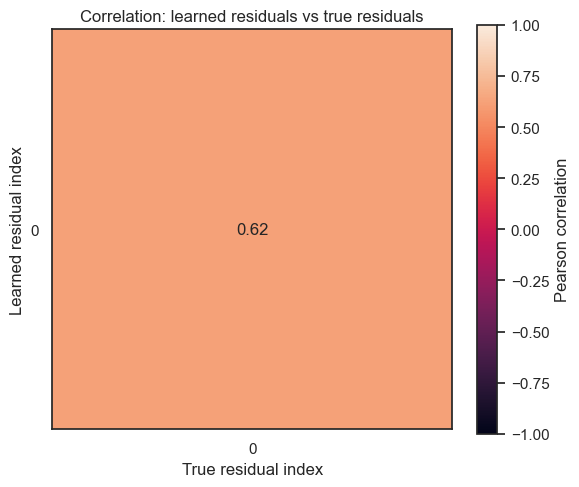

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 1.0, gamma: 0
rho: 0
Concepts linked to residuals (concept index, residual index): [(9, 0), (1, 0), (5, 0), (0, 0), (2, 0)]
----------


--- New model: scbm_residual ---
----------
Linear model test accuracy: 0.498
----------

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 10, gamma: 0
rho: 0
----------



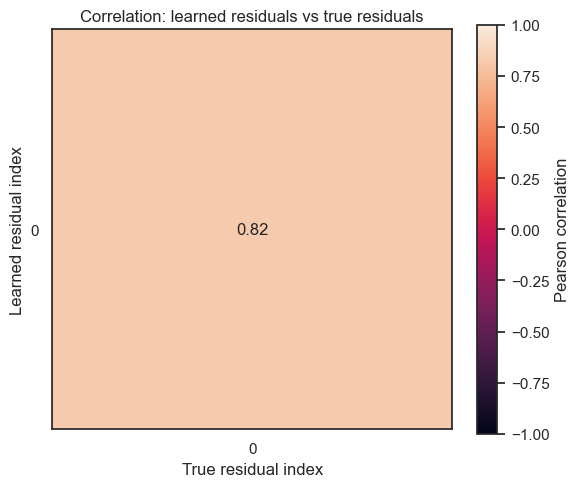

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 10, gamma: 0
rho: 0
Concepts linked to residuals (concept index, residual index): [(9, 0), (1, 0), (5, 0), (0, 0), (2, 0)]
----------



In [309]:
for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")

    model_dir = os.path.join("experiments", model, dataset, model_path)
    data_path = get_data_dir_path_from_model_log(dataset, model, model_path)
    config_dict = get_config_dict(dataset, model, model_path)
    num_concepts = config_dict["data"]["num_concepts"]
    
    y_accuracy_linear_model = get_metrics_dataset_linear_model(dataset, model, model_path)
    print("-"*10)
    print(f"Linear model test accuracy: {y_accuracy_linear_model:.3f}")
    print("-"*10 + "\n")
    
    info = dataset_info(dataset, model, model_path)
    print("-"*10)
    print(f"Dataset info:")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")
    print(f"Task weight s for concepts: {info['Task weight s for concepts']}")
    print(info["alpha"])
    print(f"rho: {info['rho_cr (correlation between linked concepts and residuals)']}")
    
    concepts_residual_pair_list = ast.literal_eval(info['Concepts linked to residuals (concept index, residual index)'])
    #print_residual_links(concepts_residual_pair_list)
    print("-"*10 + "\n")

    predicted_concepts_residuals_probs_mcmc = torch.load(
        os.path.join(model_dir, "pred_concepts_residuals_probs.pt"),
        map_location="cpu",
    )

    predicted_residuals_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, num_concepts:, :]
    predicted_concepts_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, :num_concepts, :]

    true_concepts = torch.load(
        os.path.join(data_path, "test", "concepts.pt"),
        map_location="cpu",
    )
    
    
    
    true_residuals = torch.load(
        os.path.join(data_path, "test", "residuals.pt"),
        map_location="cpu",
    )
    
    

    # print(f"Predicted residuals probabilities shape: {predicted_residuals_probs_mcmc.shape}")
    # print(f"True residuals shape: {true_residuals.shape}")
    # print(f"Predicted concepts probabilities shape: {predicted_concepts_probs_mcmc.shape}")
    # print(f"True concepts shape: {true_concepts.shape}")
    
    

    # ------------------------------------------------------------
    # Average over Monte Carlo samples
    # ------------------------------------------------------------
    # predicted_residuals_probs_mcmc: (N_test, num_residuals, num_monte_carlo)
    # predicted_residuals_probs:      (N_test, num_residuals)
    predicted_residuals_probs = predicted_residuals_probs_mcmc.mean(dim=2)
    predicted_concepts_probs = predicted_concepts_probs_mcmc.mean(dim=2)


    # ------------------------------------------------------------
    # Compute correlation matrices
    # ------------------------------------------------------------
    corr_pred_res_true_res = corr_matrix(
        predicted_residuals_probs,
        true_residuals,
    )

    corr_pred_res_true_concepts = corr_matrix(
        predicted_residuals_probs,
        true_concepts,
    )

    corr_pred_res_pred_concepts = corr_matrix(
        predicted_residuals_probs,
        predicted_concepts_probs,
    )
    
    corr_true_res_true_concepts = corr_matrix(
        true_residuals,
        true_concepts,
    )




    # ------------------------------------------------------------
    # Plot 1: learned residuals vs true residuals
    # ------------------------------------------------------------
    plot_corr_heatmap(
        corr_pred_res_true_res,
        x_label="True residual index",
        y_label="Learned residual index",
        title="Correlation: learned residuals vs true residuals",
        figsize=(6, 5),
    )


    # ------------------------------------------------------------
    # Plot 2: learned residuals vs true observed concepts
    # ------------------------------------------------------------
    # plot_corr_heatmap(
    #     corr_pred_res_true_concepts,
    #     x_label="True concept index",
    #     y_label="Learned residual index",
    #     title="Correlation: learned residuals vs true concepts",
    #     figsize=(10, 5),
    # )
    


    # ------------------------------------------------------------
    # Plot 3: learned residuals vs predicted concepts
    # ------------------------------------------------------------
    # plot_corr_heatmap(
    #     corr_pred_res_pred_concepts,
    #     x_label="Predicted concept index",
    #     y_label="Learned residual index",
    #     title="Correlation: learned residuals vs predicted concepts",
    #     figsize=(10, 5),
    # )

    # ------------------------------------------------------------
    # Plot 3: true residuals vs true concepts
    # ------------------------------------------------------------
    # plot_corr_heatmap(
    #     corr_true_res_true_concepts,
    #     x_label="True concept index",
    #     y_label="True residual index",
    #     title="Correlation: true residuals vs true concepts",
    #     figsize=(10, 5),
    # )

    # ------------------------------------------------------------
    # Print dataset info again
    # ------------------------------------------------------------
    info = dataset_info(dataset, model, model_path)
    print("-"*10)
    print(f"Dataset info:")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")
    print(f"Task weight s for concepts: {info['Task weight s for concepts']}")
    print(info["alpha"])
    print(f"rho: {info['rho_cr (correlation between linked concepts and residuals)']}")
    print(f"Concepts linked to residuals (concept index, residual index): {info['Concepts linked to residuals (concept index, residual index)']}")
    print("-"*10 + "\n")


    # ------------------------------------------------------------
    # Optional: print maximum absolute correlations
    # ------------------------------------------------------------
    # print("\nMax |corr| between learned residuals and true residuals:")
    # print(corr_pred_res_true_res.abs().max(dim=1).values)

    # print("\nMax |corr| between learned residuals and true concepts:")
    # print(corr_pred_res_true_concepts.abs().max(dim=1).values)

    # print("\nMax |corr| between learned residuals and predicted concepts:")
    # print(corr_pred_res_pred_concepts.abs().max(dim=1).values)
    


In [302]:
def residual_accuracy(predicted_residuals_probs, true_residuals):
    predicted_residuals = (predicted_residuals_probs > 0.5).float()
    correct = (predicted_residuals == true_residuals).float()
    accuracy = correct.mean().item()
    return accuracy

for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")

    model_dir = os.path.join("experiments", model, dataset, model_path)
    data_path = get_data_dir_path_from_model_log(dataset, model, model_path)
    config_dict = get_config_dict(dataset, model, model_path)
    num_concepts = config_dict["data"]["num_concepts"]
    
    y_accuracy_linear_model = get_metrics_dataset_linear_model(dataset, model, model_path)
    print("-"*10)
    print(f"Linear model test accuracy: {y_accuracy_linear_model:.3f}")
    print("-"*10 + "\n")
    
    info = dataset_info(dataset, model, model_path)
    print("-"*10)
    print(f"Dataset info:")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")
    print(f"Task weight s for concepts: {info['Task weight s for concepts']}")
    print(info["alpha"])
    print(f"rho: {info['rho_cr (correlation between linked concepts and residuals)']}")
    
    concepts_residual_pair_list = ast.literal_eval(info['Concepts linked to residuals (concept index, residual index)'])
    print_residual_links(concepts_residual_pair_list)
    print("-"*10 + "\n")
    
    predicted_concepts_residuals_probs_mcmc = torch.load(
        os.path.join(model_dir, "pred_concepts_residuals_probs.pt"),
        map_location="cpu",
    )

    predicted_residuals_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, num_concepts:, :]
    predicted_concepts_probs_mcmc = predicted_concepts_residuals_probs_mcmc[:, :num_concepts, :]

    true_concepts = torch.load(
        os.path.join(data_path, "test", "concepts.pt"),
        map_location="cpu",
    )
    
    
    
    true_residuals = torch.load(
        os.path.join(data_path, "test", "residuals.pt"),
        map_location="cpu",
    )
    
    
    
    

    # ------------------------------------------------------------
    # Average over Monte Carlo samples
    # ------------------------------------------------------------
    predicted_residuals_probs = predicted_residuals_probs_mcmc.mean(dim=2)
    predicted_concepts_probs = predicted_concepts_probs_mcmc.mean(dim=2)
    
    res_acc = residual_accuracy(predicted_residuals_probs, true_residuals)
    print(f"Residual accuracy (thresholding at 0.5): {res_acc:.3f}")
    
    


--- New model: scbm_residual ---
----------
Linear model test accuracy: 1.000
----------

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 0, gamma: 0
rho: 0
r0 is linked to c9, c1, c5, c0, c2
----------

Residual accuracy (thresholding at 0.5): 0.509

--- New model: scbm_residual ---
----------
Linear model test accuracy: 0.693
----------

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 1.0, gamma: 0
rho: 0
r0 is linked to c9, c1, c5, c0, c2
----------

Residual accuracy (thresholding at 0.5): 0.791

--- New model: scbm_residual ---
----------
Linear model test accuracy: 0.498
----------

----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300

# Classwise Mu

In [303]:
for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")
    info = dataset_info(dataset, model, model_path)
    print("-"*10)
    print(f"Dataset info:")
    print(f"Task weight s for concepts: {info['Task weight s for concepts']}")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")
    print(info["alpha"])
    print("-"*10 + "\n")
    config = get_config_dict(dataset, model, model_path)
    num_concepts = config["data"]["num_concepts"]
    num_residuals = config["data"]["num_residuals"]
    model_dir_path = os.path.join("experiments", model, dataset, model_path)
    mu = torch.load(os.path.join(model_dir_path, "classwise_mu.pt"))
    for class_id, mu in mu.items():
        print(f"Class {class_id}:")
        print("Concept mean (mu):", mu[:num_concepts])
        print("Residual mean (mu):", mu[num_concepts:num_concepts+num_residuals])

    if model == "scbm_residual":
        W_c, W_r = get_final_layer_weights(dataset, model, model_path)
        print("W_c:", W_c)
        print("W_r:", W_r)
    elif model == "scbm":
        W_c,_ = get_final_layer_weights(dataset, model, model_path)
        #print(f"W_c shape: {W_c.shape}")
        print("W_c:", W_c)

        



--- New model: scbm_residual ---
----------
Dataset info:
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
Task weight s for residuals: [-1.0]
1.0, beta: 0, gamma: 0
----------

Class 0:
Concept mean (mu): tensor([ 0.0348, -0.2673,  0.0849,  0.2163, -4.6278,  0.1874, -0.0284,  0.0239,
         0.1073, -0.0773])
Residual mean (mu): tensor([9.6770])
Class 1:
Concept mean (mu): tensor([-0.1118, -0.0606, -0.1081,  0.3074,  4.7988,  0.0430,  0.1582, -0.1122,
        -0.0205,  0.2490])
Residual mean (mu): tensor([-10.1607])
Using residual model!
Loaded model from experiments/scbm_residual/synthetic_res_scbm/alpha_1.0_beta_0_gamma_0_rho_0_ratio_pairs_0.5_200_epochs_1_residual_2026-05-29_12-28-20_440fd/model.pth
W_c: tensor([[-0.0411,  0.2114, -0.0161, -0.0905,  0.7631,  0.1666, -0.0491,  0.0678,
         -0.0496,  0.1436]])
W_r: tensor([[-1.0783]])

--- New model: scbm_residual ---
----------
Dataset info:
Task weigh

# Classwise covariance matrix

In [304]:
def cov_to_corr(cov_matrix):
    """Convert covariance matrix to correlation matrix."""
    if hasattr(cov_matrix, "numpy"):
        cov_matrix = cov_matrix.numpy()
    std = np.sqrt(np.diag(np.diag(cov_matrix)))
    corr = np.linalg.inv(std) @ cov_matrix @ np.linalg.inv(std)
    return corr


In [305]:
def plot_cov_heatmap(
    cov,
    num_concepts,
    num_residuals,
    title,
    figsize=(7, 5),
    show_values=True,
    concept_residual=False,
    get_top10_covariances=False
):
    """
    Plot covariance matrix for z = [concepts, residuals].

    If concept_residual=False:
        plot full covariance matrix:

            [ Cov(c, c)   Cov(c, r) ]
            [ Cov(r, c)   Cov(r, r) ]

    If concept_residual=True:
        plot only concept rows:

            [ Cov(c, c)   Cov(c, r) ]

        This shows how concepts covary with both concepts and residuals.
    """

    if isinstance(cov, torch.Tensor):
        cov = cov.detach().cpu()
    else:
        cov = torch.tensor(cov)

    expected_dim = num_concepts + num_residuals
    assert cov.shape == (expected_dim, expected_dim), (
        f"Expected covariance matrix of shape "
        f"{(expected_dim, expected_dim)}, but got {tuple(cov.shape)}"
    )

    # ------------------------------------------------------------
    # Print top 10 concept-residual covariances only
    # ------------------------------------------------------------
    if get_top10_covariances:
        concept_residual_cov = cov[:num_concepts, num_concepts:]

        values = concept_residual_cov.flatten()

        top_k = min(10, values.numel())
        _, top_indices = torch.topk(values.abs(), k=top_k)

        print("\nTop concept-residual covariances:")
        print("-" * 50)

        for rank, flat_idx in enumerate(top_indices, start=1):
            concept_idx = flat_idx // num_residuals
            residual_idx = flat_idx % num_residuals

            cov_value = concept_residual_cov[concept_idx, residual_idx].item()

            print(
                f"{rank:2d}. "
                f"Cov(c{concept_idx.item()}, r{residual_idx.item()}) "
                f"= {cov_value:.4f} "
                f"(abs = {abs(cov_value):.4f})"
            )

    full_labels = (
        [f"c{i}" for i in range(num_concepts)]
        + [f"r{i}" for i in range(num_residuals)]
    )

    if concept_residual:
        # Keep only concept rows, but all concept + residual columns
        cov_plot = cov[:num_concepts, :]

        x_labels = full_labels
        y_labels = [f"c{i}" for i in range(num_concepts)]

        xlabel = "Concepts and residuals"
        ylabel = "Concepts"

    else:
        cov_plot = cov

        x_labels = full_labels
        y_labels = full_labels

        xlabel = "Concepts and residuals"
        ylabel = "Concepts and residuals"

    max_abs = cov_plot.abs().max().item()

    plt.figure(figsize=figsize)
    plt.imshow(
        cov_plot.numpy(),
        vmin=-max_abs,
        vmax=max_abs,
        aspect="auto",
    )
    plt.colorbar(label="Covariance")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.xticks(np.arange(cov_plot.shape[1]), x_labels, rotation=90)
    plt.yticks(np.arange(cov_plot.shape[0]), y_labels)

    # Draw vertical separator between concept columns and residual columns
    boundary = num_concepts - 0.5
    plt.axvline(boundary, color="black", linewidth=1.5)

    # Draw horizontal separator only for the full matrix
    if not concept_residual:
        plt.axhline(boundary, color="black", linewidth=1.5)

    # Add block labels on x-axis
    plt.text(
        num_concepts / 2 - 0.5,
        -1.2,
        "Concepts",
        ha="center",
        va="center",
        fontweight="bold",
    )

    plt.text(
        num_concepts + num_residuals / 2 - 0.5,
        -1.2,
        "Residuals",
        ha="center",
        va="center",
        fontweight="bold",
    )

    if show_values:
        for i in range(cov_plot.shape[0]):
            for j in range(cov_plot.shape[1]):
                plt.text(
                    j,
                    i,
                    f"{cov_plot[i, j].item():.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.tight_layout()
    plt.show()


--- New model: scbm_residual ---
----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 0, gamma: 0
rho: 0
----------

Class 0:


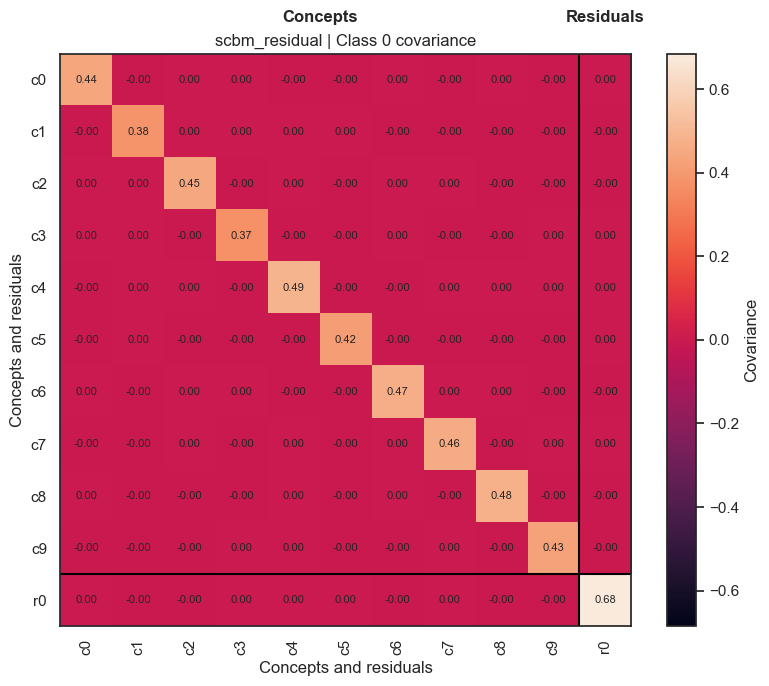

Class 1:


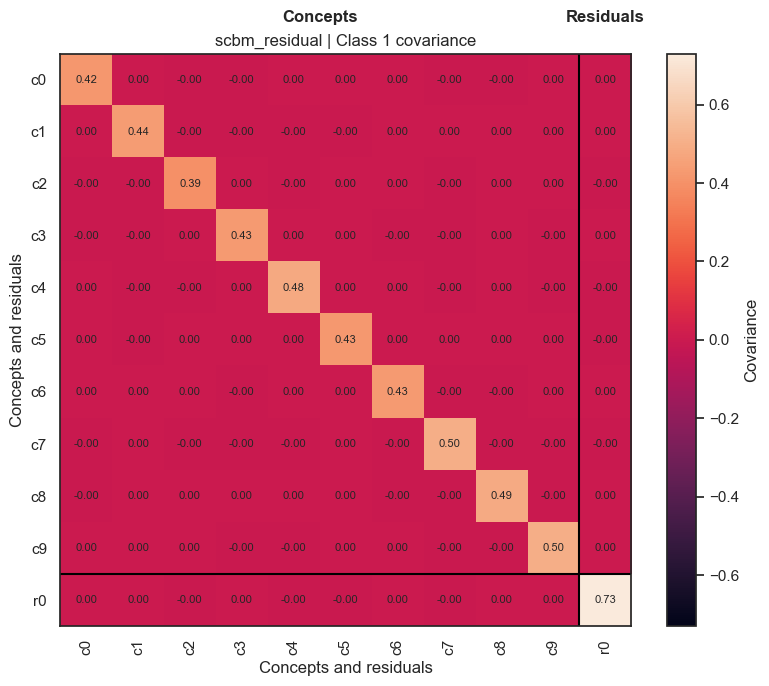

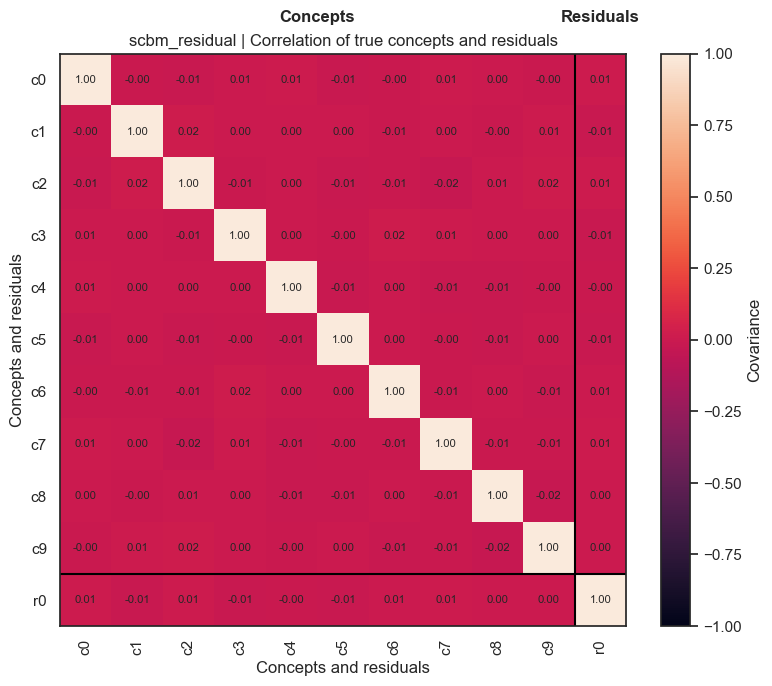

r0 is linked to c9, c1, c5, c0, c2

--- New model: scbm_residual ---
----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 1.0, gamma: 0
rho: 0
----------

Class 0:


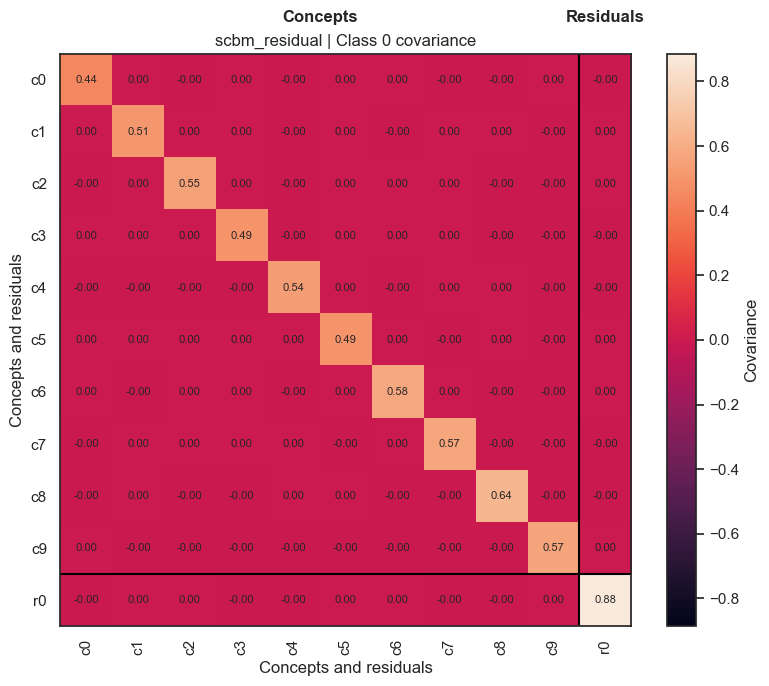

Class 1:


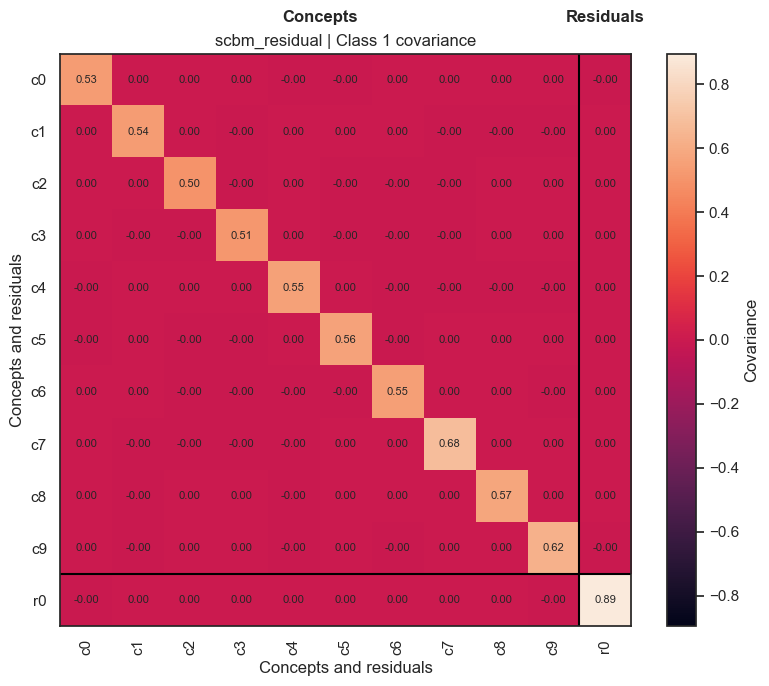

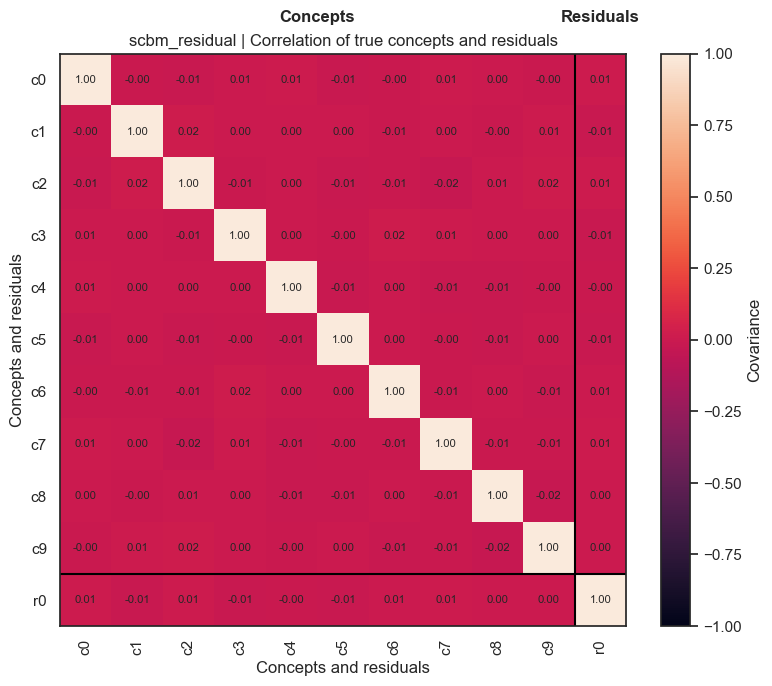

r0 is linked to c9, c1, c5, c0, c2

--- New model: scbm_residual ---
----------
Dataset info:
Task weight s for residuals: [-1.0]
Task weight s for concepts: [0.0, 0.20978300273418427, 0.0, 0.23463578522205353, 0.949177086353302, 0.0, 0.0, 0.0, 0.0, 0.0]
1.0, beta: 10, gamma: 0
rho: 0
----------

Class 0:


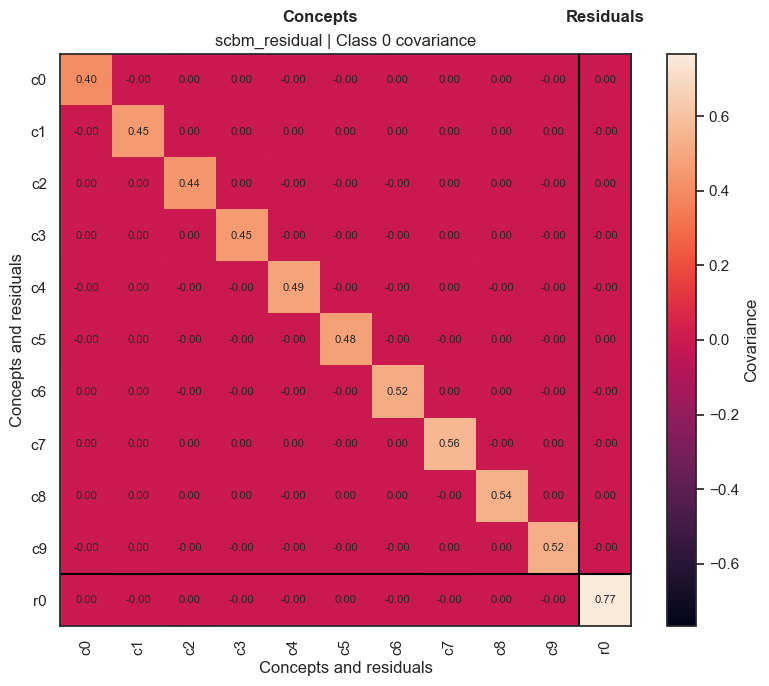

Class 1:


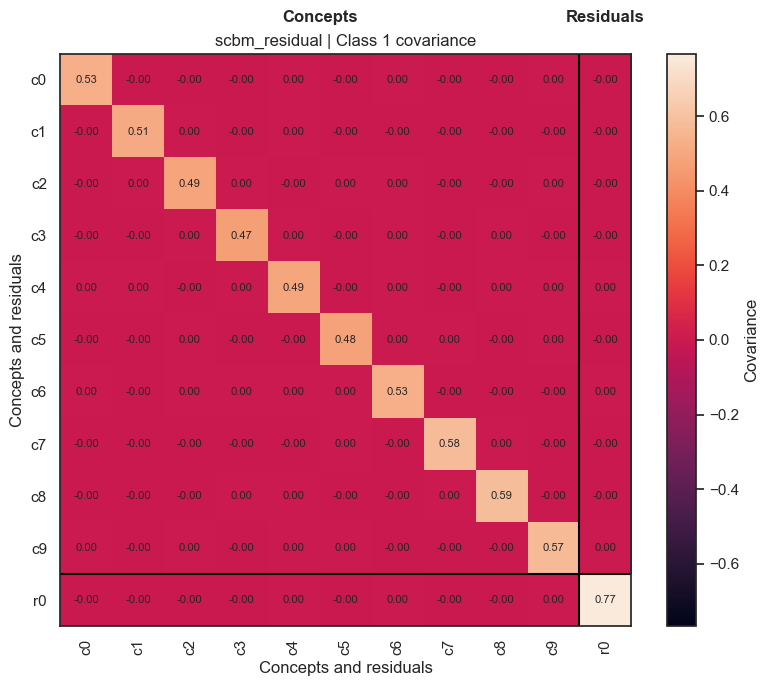

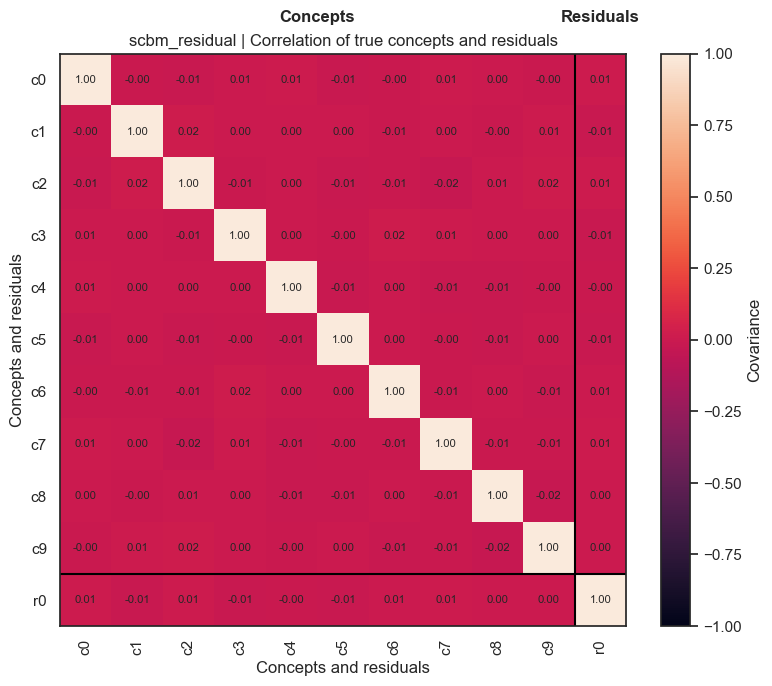

r0 is linked to c9, c1, c5, c0, c2


In [306]:
for dataset, model, model_path in models:
    print(f"\n--- New model: {model} ---")
    data_path = get_data_dir_path_from_model_log(dataset, model, model_path)
    
    info = dataset_info(dataset, model, model_path)
    print("-"*10)
    print(f"Dataset info:")
    print(f"Task weight s for residuals: {info['Task weight s for residuals']}")
    print(f"Task weight s for concepts: {info['Task weight s for concepts']}")
    print(info["alpha"])
    print(f"rho: {info['rho_cr (correlation between linked concepts and residuals)']}")
    concepts_residual_pair_list = ast.literal_eval(info['Concepts linked to residuals (concept index, residual index)'])
        
    print("-"*10 + "\n")
    
    config = get_config_dict(dataset, model, model_path)
    num_concepts = config["data"]["num_concepts"]
    num_residuals = config["data"]["num_residuals"]
    model_dir_path = os.path.join("experiments", model, dataset, model_path)
    covariance_gaussian = torch.load(os.path.join(model_dir_path, "classwise_covariances.pt"))
    
    true_concepts = torch.load(
    os.path.join(data_path, "test", "concepts.pt"),
    map_location="cpu",
)
    
    
    
    true_residuals = torch.load(
        os.path.join(data_path, "test", "residuals.pt"),
        map_location="cpu",
    )
    
    true_concept_residuals = torch.cat([true_concepts, true_residuals], dim=1)
    
    corr_true_res_true_concepts = corr_matrix(
        true_concept_residuals,
        true_concept_residuals,
    )
    
    
    for class_id, cov in covariance_gaussian.items():
        print(f"Class {class_id}:")
        plot_cov_heatmap(
            cov=cov,
            num_concepts=num_concepts,
            num_residuals=num_residuals,
            title=f"{model} | Class {class_id} covariance",
            figsize=(8, 7),
            show_values=True,
        )
    
    plot_cov_heatmap(
        cov=corr_true_res_true_concepts,
        num_concepts=num_concepts,
        num_residuals=num_residuals,
        title=f"{model} | Correlation of true concepts and residuals",
        figsize=(8, 7),
        show_values=True,
    )

    print_residual_links(concepts_residual_pair_list)

        

# Check datasets

In [307]:
root = "datasets/synthetic_res_scbm"
data1 = "cluster_a_1.0_b_1.0_g_0_rho_0.3_seed_0"
data2 = "cluster_a_1.0_b_1.0_g_0_rho_0.7_seed_0"

datasets = [data1, data2]
splits = ["train", "val", "test"]

data_dict = {}

for data_dir in datasets:
    for split in splits:
        if not os.path.exists(os.path.join(root, data_dir, split)):
            print(f"Directory not found: {os.path.join(root, data_dir, split)}")
            continue
        print(f"Loading data from {data_dir} for split {split}")
        x_path = os.path.join(root, data_dir, split, "x.pt")
        print(f"Loading x from {x_path}")
        y_path = os.path.join(root, data_dir, split, "y.pt")
        s_path = os.path.join(root, data_dir, split, "s.pt")
        x = torch.load(x_path)
        y = torch.load(y_path)
        s = torch.load(s_path)
        print(x.shape, y.shape, s.shape)
        data_dict[(data_dir, split)] = (x, y, s)
        
for split in splits:
    x1, y1, s1 = data_dict[(data1, split)]
    x2, y2, s2 = data_dict[(data2, split)]
    # Check if x1 and x2 are the same
    if torch.allclose(x1, x2):
        print(f"x tensors are the same for split {split}")
    else:
        print(f"x tensors differ for split {split}")
    # Check if y1 and y2 are the same
    if torch.allclose(y1, y2):
        print(f"y tensors are the same for split {split}")
    else:
        print(f"y tensors differ for split {split}")
    # Check if s1 and s2 are the same
    if torch.allclose(s1, s2):
        print(f"s tensors are the same for split {split}")
    else:
        print(f"s tensors differ for split {split}")
    


Directory not found: datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.3_seed_0/train
Directory not found: datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.3_seed_0/val
Directory not found: datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.3_seed_0/test
Directory not found: datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.7_seed_0/train
Directory not found: datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.7_seed_0/val
Directory not found: datasets/synthetic_res_scbm/cluster_a_1.0_b_1.0_g_0_rho_0.7_seed_0/test


KeyError: ('cluster_a_1.0_b_1.0_g_0_rho_0.3_seed_0', 'train')

# CUB 

Class 0:

Top concept-residual covariances:
--------------------------------------------------
 1. Cov(c6, r41) = 0.3490 (abs = 0.3490)
 2. Cov(c20, r8) = 0.3441 (abs = 0.3441)
 3. Cov(c20, r33) = -0.3405 (abs = 0.3405)
 4. Cov(c5, r14) = -0.3196 (abs = 0.3196)
 5. Cov(c5, r47) = -0.3169 (abs = 0.3169)
 6. Cov(c9, r36) = 0.3162 (abs = 0.3162)
 7. Cov(c5, r3) = 0.3129 (abs = 0.3129)
 8. Cov(c6, r2) = -0.3069 (abs = 0.3069)
 9. Cov(c1, r40) = 0.3051 (abs = 0.3051)
10. Cov(c20, r34) = 0.3039 (abs = 0.3039)


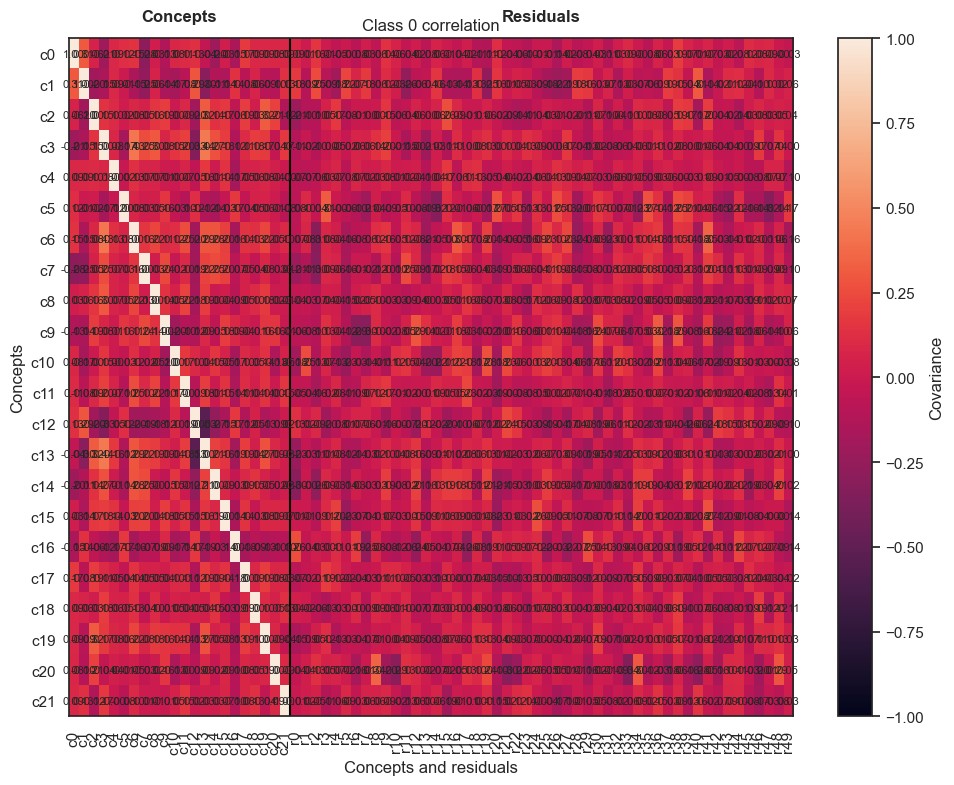

Class 1:

Top concept-residual covariances:
--------------------------------------------------
 1. Cov(c5, r43) = -0.3017 (abs = 0.3017)
 2. Cov(c20, r8) = 0.2946 (abs = 0.2946)
 3. Cov(c6, r2) = -0.2745 (abs = 0.2745)
 4. Cov(c12, r41) = -0.2718 (abs = 0.2718)
 5. Cov(c5, r39) = 0.2696 (abs = 0.2696)
 6. Cov(c12, r39) = -0.2659 (abs = 0.2659)
 7. Cov(c3, r27) = 0.2652 (abs = 0.2652)
 8. Cov(c5, r14) = -0.2633 (abs = 0.2633)
 9. Cov(c16, r29) = 0.2614 (abs = 0.2614)
10. Cov(c16, r7) = -0.2573 (abs = 0.2573)


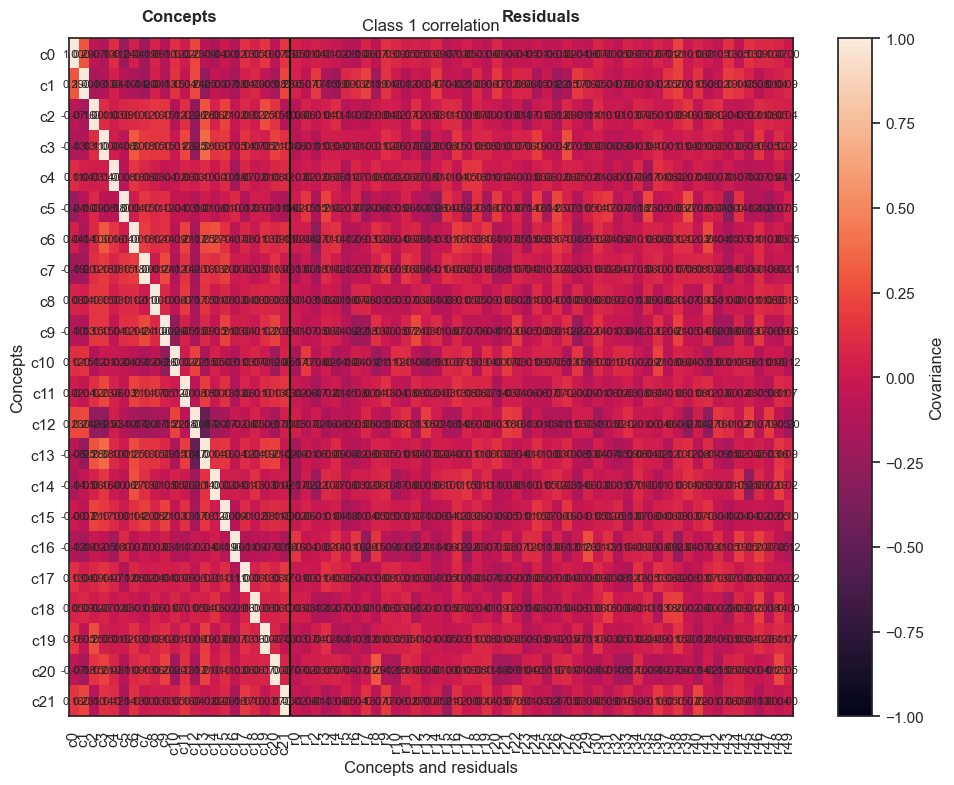

Class 2:

Top concept-residual covariances:
--------------------------------------------------
 1. Cov(c5, r47) = -0.3591 (abs = 0.3591)
 2. Cov(c9, r36) = 0.3383 (abs = 0.3383)
 3. Cov(c6, r41) = 0.3283 (abs = 0.3283)
 4. Cov(c9, r6) = -0.3205 (abs = 0.3205)
 5. Cov(c6, r2) = -0.3199 (abs = 0.3199)
 6. Cov(c5, r3) = 0.2961 (abs = 0.2961)
 7. Cov(c2, r38) = 0.2909 (abs = 0.2909)
 8. Cov(c5, r14) = -0.2908 (abs = 0.2908)
 9. Cov(c20, r48) = 0.2845 (abs = 0.2845)
10. Cov(c20, r34) = 0.2843 (abs = 0.2843)


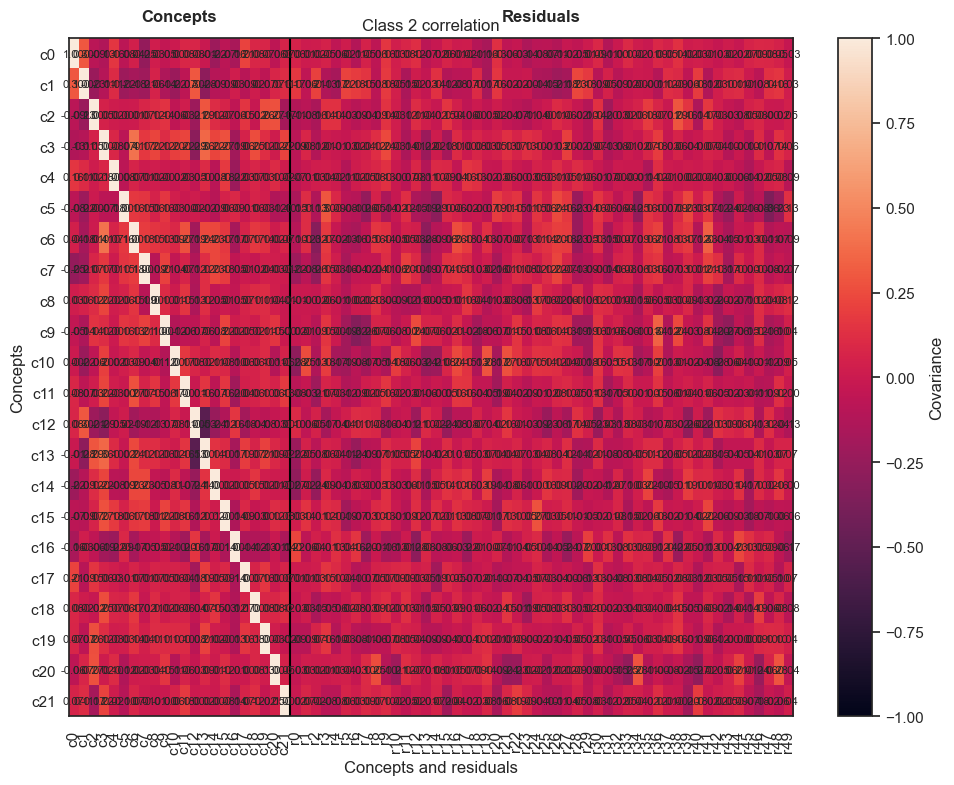

Class 3:

Top concept-residual covariances:
--------------------------------------------------
 1. Cov(c2, r19) = 0.3681 (abs = 0.3681)
 2. Cov(c2, r29) = -0.3243 (abs = 0.3243)
 3. Cov(c5, r28) = -0.3234 (abs = 0.3234)
 4. Cov(c5, r20) = 0.3198 (abs = 0.3198)
 5. Cov(c7, r44) = 0.2843 (abs = 0.2843)
 6. Cov(c2, r30) = -0.2732 (abs = 0.2732)
 7. Cov(c15, r17) = 0.2721 (abs = 0.2721)
 8. Cov(c14, r36) = -0.2615 (abs = 0.2615)
 9. Cov(c5, r3) = 0.2610 (abs = 0.2610)
10. Cov(c5, r44) = -0.2543 (abs = 0.2543)


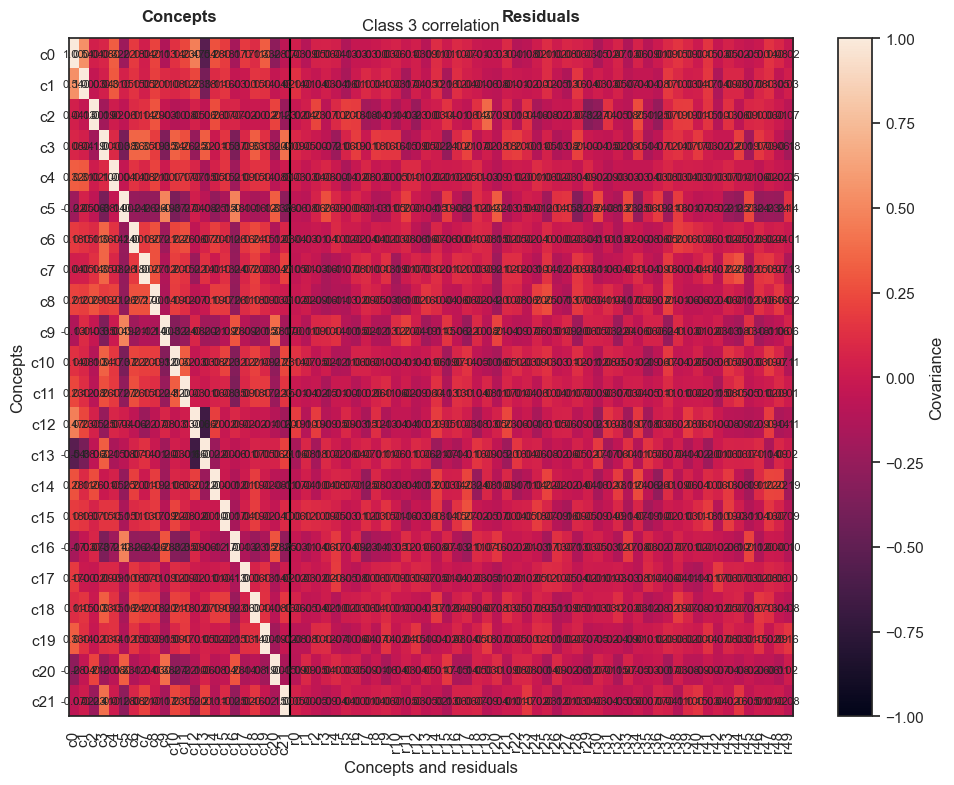

Class 4:

Top concept-residual covariances:
--------------------------------------------------
 1. Cov(c9, r44) = 0.3660 (abs = 0.3660)
 2. Cov(c5, r26) = 0.3558 (abs = 0.3558)
 3. Cov(c10, r44) = -0.3354 (abs = 0.3354)
 4. Cov(c5, r3) = 0.3109 (abs = 0.3109)
 5. Cov(c12, r8) = 0.3086 (abs = 0.3086)
 6. Cov(c7, r15) = 0.2857 (abs = 0.2857)
 7. Cov(c13, r8) = -0.2844 (abs = 0.2844)
 8. Cov(c7, r44) = 0.2840 (abs = 0.2840)
 9. Cov(c10, r15) = -0.2832 (abs = 0.2832)
10. Cov(c19, r48) = 0.2820 (abs = 0.2820)


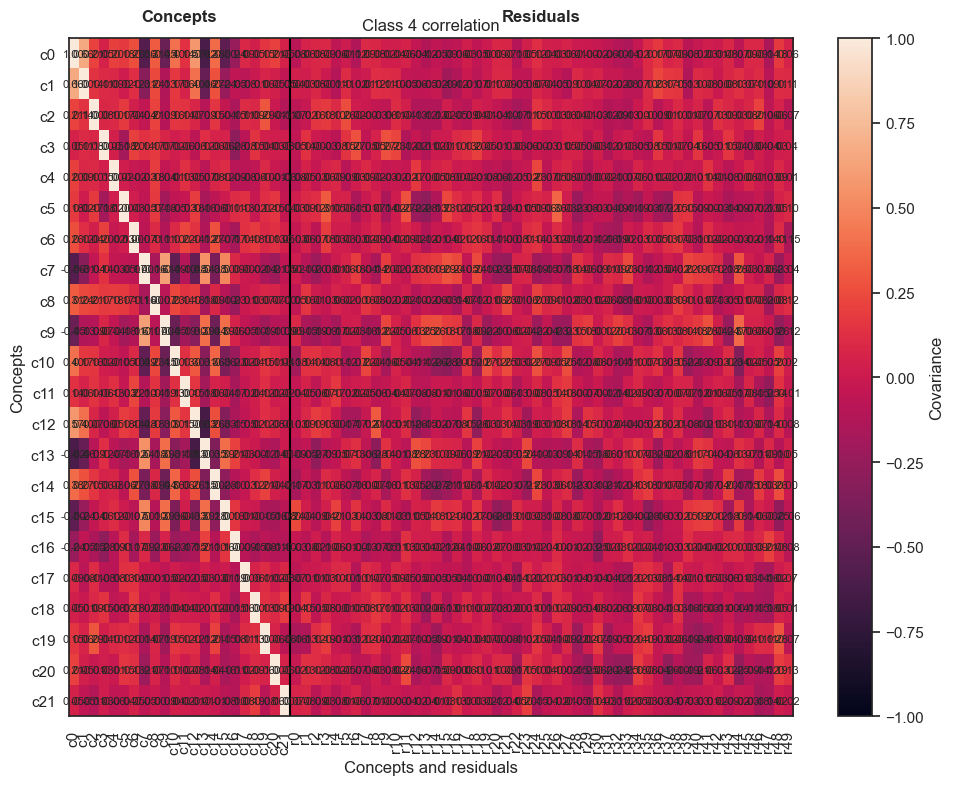

In [ ]:
covariances = torch.load(os.path.join("experiments", "scbm_residual", "CUB", "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_10_2026-05-12_18-09-57_8a33c", "classwise_covariances.pt"))

i = 0
for class_id, cov in covariances.items():
    if i == 5:
        break
    i += 1
    
    cor = cov_to_corr(cov)
    
    print(f"Class {class_id}:")
    plot_cov_heatmap(
        cov=cor,
        num_concepts=22,
        num_residuals=50,
        title=f"Class {class_id} correlation",
        figsize=(10, 8),
        concept_residual=True,
        get_top10_covariances=True,
    )